#**HATE SPEECH MODEL USING RANDOM FOREST**
**Following notebook train and save hyperparameters of a Random Forest on a hate speech dataset**

[You can download the dataset used from here](https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/)

[Glove word embeddings used can be downloaded from here](https://nlp.stanford.edu/projects/glove/)

In [5]:
from __future__ import print_function, division
from builtins import range
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.layers import Dense, Input, GlobalMaxPool1D,Bidirectional,LSTM
from keras.layers import Conv1D, MaxPooling1D, Embedding
from keras.models import Model
from keras.layers import SpatialDropout1D,Dropout
from sklearn.metrics import roc_auc_score
from keras.models import model_from_json
from keras import regularizers

In [6]:
# some configuration
MAX_SEQUENCE_LENGTH = 200
MAX_VOCAB_SIZE = 22000
EMBEDDING_DIM = 50
VALIDATION_SPLIT = 0.2
BATCH_SIZE = 128
EPOCHS = 5

In [7]:
print('Loading word vectors...')
word2vec = {}
with open(os.path.join('../../Data/glove.6B/glove.6B.%sd.txt' % EMBEDDING_DIM)) as f:
  # word embedding file is just a space-separated text file in the format:
  # word vec[0] vec[1] vec[2] ...
  for line in f:
    values = line.split()
    word = values[0]
    vec = np.asarray(values[1:], dtype='float32')
    word2vec[word] = vec
print('Found %s word vectors.' % len(word2vec))

Loading word vectors...
Found 61386 word vectors.


In [9]:
# prepare text samples and their labels
print('Loading in comments...')

train = pd.read_csv("../../Data/toxic-comment/train.csv")
sentences = train["comment_text"].fillna("DUMMY_VALUE").values # there are no na values in the data though
possible_labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
targets = train[possible_labels].values
print ("Shape of data:",(train.shape))
print ("First 5 rows:",(train.head()))

Loading in comments...
Shape of data: (159571, 8)
First 5 rows:                  id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [10]:
# convert the sentences (strings) into integers
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)

print("max sequence length:", max(len(s) for s in sequences))
print("min sequence length:", min(len(s) for s in sequences))
s = sorted(len(s) for s in sequences)
print("median sentences length:", s[len(s) // 2])

max sequence length: 1400
min sequence length: 0
median sentences length: 35


In [11]:
# get word -> integer mapping
word2idx = tokenizer.word_index
data = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)
print('Found %s unique tokens.' % len(word2idx))

Found 210337 unique tokens.


In [12]:
# prepare embedding matrix
print('Filling pre-trained embeddings...')
num_words = min(MAX_VOCAB_SIZE, len(word2idx) + 1)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
for word, i in word2idx.items():
  if i < MAX_VOCAB_SIZE:
    embedding_vector = word2vec.get(word)
    if embedding_vector is not None:
      # words not found in embedding index will be all zeros.
      embedding_matrix[i] = embedding_vector

print('Completed...')

Filling pre-trained embeddings...
Completed...


In [13]:
# Install necessary libraries
!pip install scikit-learn pandas numpy

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

# Load the data
print('Loading in comments...')
train = pd.read_csv("../../Data/toxic-comment/train.csv")
sentences = train["comment_text"].fillna("DUMMY_VALUE").values
possible_labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
targets = train[possible_labels].values

# Convert text data to TF-IDF features
print('Converting text to TF-IDF features...')
vectorizer = TfidfVectorizer(max_features=MAX_VOCAB_SIZE)
X = vectorizer.fit_transform(sentences)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, targets, test_size=VALIDATION_SPLIT, random_state=42)

# Train a Random Forest classifier
print('Training Random Forest model...')
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Evaluate the model
print('Evaluating model...')
y_pred = rf_model.predict_proba(X_val)

# Calculate AUC for each label
aucs = []
for j in range(len(possible_labels)):
    auc = roc_auc_score(y_val[:, j], y_pred[j][:, 1])
    aucs.append(auc)
    print(f"AUC for {possible_labels[j]}: {auc}")

print(f"Mean AUC: {np.mean(aucs)}")

# Calculate accuracy
y_pred_labels = rf_model.predict(X_val)
accuracy = accuracy_score(np.argmax(y_val, axis=1), np.argmax(y_pred_labels, axis=1))
print(f"Accuracy: {accuracy}")

Loading in comments...
Converting text to TF-IDF features...
Training Random Forest model...
Evaluating model...
AUC for toxic: 0.9658148952326249
AUC for severe_toxic: 0.9782953977814708
AUC for obscene: 0.9858677523989728
AUC for threat: 0.9491342965087508
AUC for insult: 0.9753305404547606
AUC for identity_hate: 0.9388035312793723
Mean AUC: 0.9655410689426588
Accuracy: 0.993921353595488


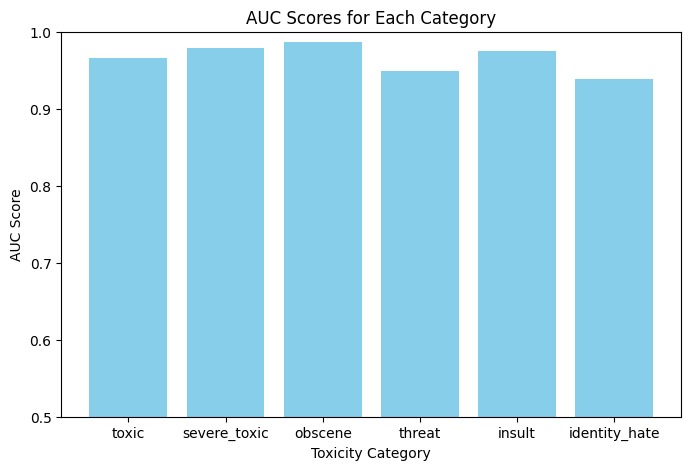

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.bar(possible_labels, aucs, color='skyblue')
plt.xlabel("Toxicity Category")
plt.ylabel("AUC Score")
plt.title("AUC Scores for Each Category")
plt.ylim(0.5, 1)  # AUC ranges from 0.5 (random) to 1 (perfect)
plt.show()


In [20]:
import json
import joblib
import gzip
# Save model parameters
model_params = {
    "n_estimators": rf_model.n_estimators,
    "max_depth": rf_model.max_depth,
    "max_features": rf_model.max_features,
    "random_state": rf_model.random_state
}

# Save to JSON file
with open("../../output/rf_hate_speech_hyperparameters.json", "w") as f:
    json.dump(model_params, f, indent=4)

joblib.dump(rf_model, "../../output/rf_model_compressed.pkl", compress=3)

print("Fully trained model and its architecture is saved to disk")


Fully trained model and its architecture is saved to disk
